# **1. Perkenalan Dataset**


Tahap pertama

1. **Sumber Dataset**:  
Dataset yang digunakan adalah **Titanic Dataset**. Dataset ini berisi informasi mengenai penumpang kapal Titanic seperti usia, jenis kelamin, kelas tiket, dan status keselamatan mereka (Survived). Tujuan dari eksperimen ini adalah membersihkan data agar siap digunakan untuk model klasifikasi yang memprediksi apakah seorang penumpang selamat (1) atau tidak (0).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat data mentah. Sesuaikan path dengan lokasi foldermu.
# Karena di kriteria 1 disarankan menggunakan folder dataset_raw:
file_path = 'C:\\Users\\Jauhanunu\\Documents\\Pijak\\SMSML_Jauhan-Ahmad\\Eksperimen_SML_Jauhan\\dataset_raw\\Titanic-Dataset.csv' 
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Struktur Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Pengecekan Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Far

C:\Users\Jauhanunu\AppData\Local\Temp\ipykernel_5380\862363145.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='Set1')


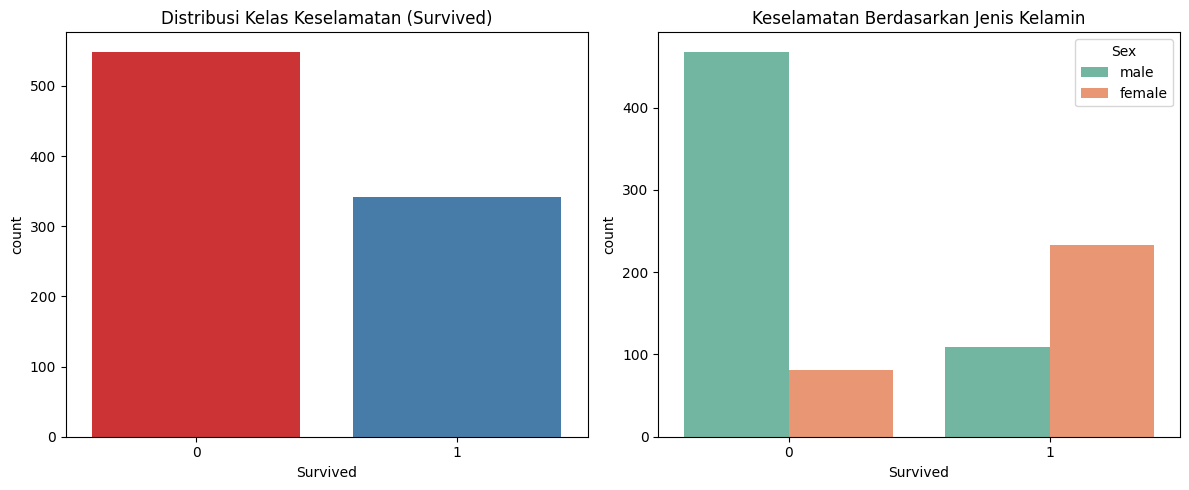

In [3]:
print("--- Informasi Struktur Dataset ---")
df.info()

print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum())

print("\n--- Pengecekan Data Duplikat ---")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Visualisasi Distribusi Target (Survived)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Survived', palette='Set1')
plt.title('Distribusi Kelas Keselamatan (Survived)')

# Visualisasi Keselamatan berdasarkan Jenis Kelamin
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Survived', hue='Sex', palette='Set2')
plt.title('Keselamatan Berdasarkan Jenis Kelamin')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
print("Memulai proses pembersihan data...")

# Salin dataframe agar data asli tidak berubah
df_clean = df.copy()

# 1. Drop kolom yang tidak relevan atau terlalu banyak missing value (Cabin)
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=cols_to_drop, inplace=True)

# 2. Imputasi (Mengisi) Missing Values
# Mengisi Age dengan nilai median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
# Mengisi Embarked dengan nilai modus (paling sering muncul)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Encoding Data Kategorikal
# Mengubah jenis kelamin menjadi angka (0 dan 1)
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# Menggunakan One-Hot Encoding untuk kolom 'Embarked' (karena ada 3 kategori: C, Q, S)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)

print("\n--- Info Data Setelah Preprocessing ---")
df_clean.info()

# 4. Menyimpan Data Bersih
output_dir = 'dataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = f'{output_dir}/data_bersih.csv'

df_clean.to_csv(output_path, index=False)
print(f"\nData berhasil dibersihkan dan disimpan di: {output_path}")
display(df_clean.head())

Memulai proses pembersihan data...


C:\Users\Jauhanunu\AppData\Local\Temp\ipykernel_5380\669612690.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
C:\Users\Jauhanunu\AppData\Local\Temp\ipykernel_5380\669612690.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves


--- Info Data Setelah Preprocessing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB

Data berhasil dibersihkan dan disimpan di: dataset_preprocessing/data_bersih.csv


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


# Penyesuaian Script automate_Jauhan.py (Untuk Target Skilled/Advance)
Karena datanya berubah, isi file automate_Jauhan.py yang sebelumnya juga harus kita ubah agar logikanya sama persis dengan sel nomor 5 di atas.

In [5]:
import pandas as pd
import os

def load_data(filepath):
    print("Loading data...")
    return pd.read_csv(filepath)

def preprocess_data(df):
    print("Preprocessing data...")
    df_clean = df.copy()
    
    # Drop kolom tidak relevan
    cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)
    
    # Imputasi Missing Values
    if 'Age' in df_clean.columns:
        df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
        
    # Encoding Data Kategorikal
    if 'Sex' in df_clean.columns:
        df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
        
    if 'Embarked' in df_clean.columns:
        df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
        
    return df_clean

def save_data(df, output_path):
    print("Saving preprocessed data...")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"Data tersimpan di {output_path}")

if __name__ == "__main__":
    input_file = "../dataset_raw/Titanic-Dataset.csv"
    output_file = "dataset_preprocessing/data_bersih.csv"

    raw_df = load_data(input_file)
    clean_df = preprocess_data(raw_df)
    save_data(clean_df, output_file)

Loading data...
Preprocessing data...
Saving preprocessed data...
Data tersimpan di dataset_preprocessing/data_bersih.csv


C:\Users\Jauhanunu\AppData\Local\Temp\ipykernel_5380\2463590012.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
C:\Users\Jauhanunu\AppData\Local\Temp\ipykernel_5380\2463590012.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav